Visualizing Data

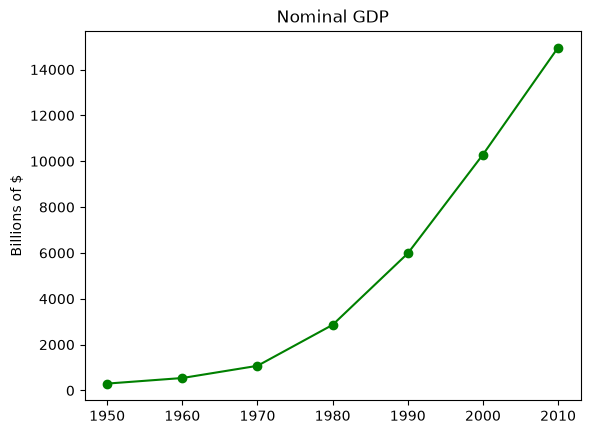

In [68]:
from matplotlib import pyplot as plt

years = [1950, 1960, 1970, 1980, 1990, 2000, 2010]
gdp = [300.2, 543.3, 1075.9, 2862.5, 5979.6, 10289.7, 14958.3]

# Create a line chart
plt.plot(years, gdp, color='green', marker='o', linestyle='solid')

plt.title("Nominal GDP")
plt.ylabel("Billions of $")
plt.show()

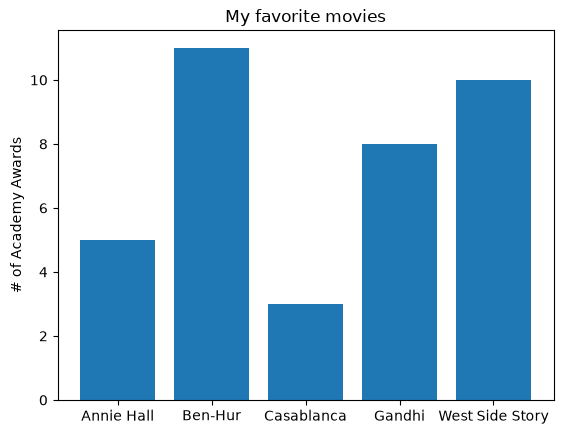

In [69]:
movies = ["Annie Hall", "Ben-Hur", "Casablanca", "Gandhi", "West Side Story"]
num_oscars = [5, 11, 3, 8, 10]

plt.bar(range(len(movies)), num_oscars)

plt.title("My favorite movies")
plt.ylabel("# of Academy Awards")
plt.xticks(range(len(movies)), movies)

plt.show()

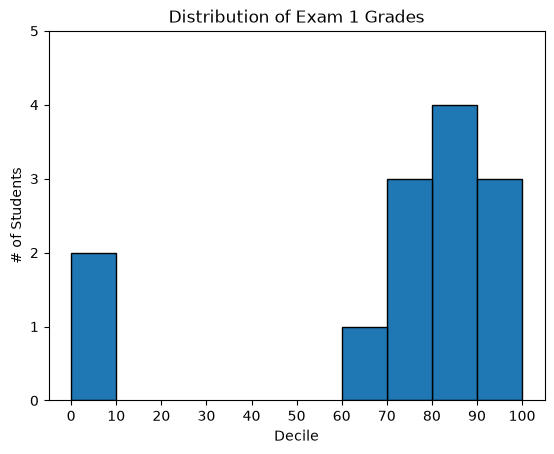

In [70]:
from collections import Counter

grades = [83, 95, 91, 87, 70, 0, 85, 82, 100, 67, 73, 77, 0]

histogram = Counter(min(grade // 10 * 10, 90) for grade in grades)

plt.bar([x + 5 for x in histogram.keys()], histogram.values(), 10, edgecolor=(0, 0, 0))

plt.axis((-5, 105, 0, 5))

plt.xticks([10 * i for i in range(11)])

plt.xlabel("Decile")
plt.ylabel("# of Students")
plt.title("Distribution of Exam 1 Grades")
plt.show()

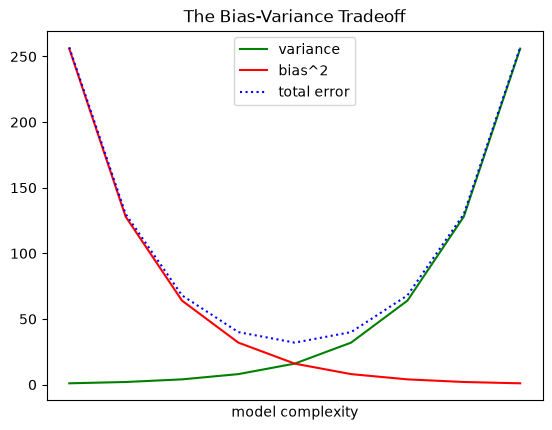

In [71]:
variance = [1, 2, 4, 8, 16, 32, 64, 128, 256]
bias_squared = [256, 128, 64, 32, 16, 8, 4, 2, 1]
total_error = [x + y for x, y in zip(bias_squared, variance)]
xss = [i for i, _ in enumerate(variance)]

plt.plot(xss, variance, 'g-', label='variance')
plt.plot(xss, bias_squared, 'r-', label='bias^2')
plt.plot(xss, total_error, 'b:', label='total error')

plt.legend(loc=9)
plt.xlabel("model complexity")
plt.xticks([])
plt.title("The Bias-Variance Tradeoff")
plt.show()

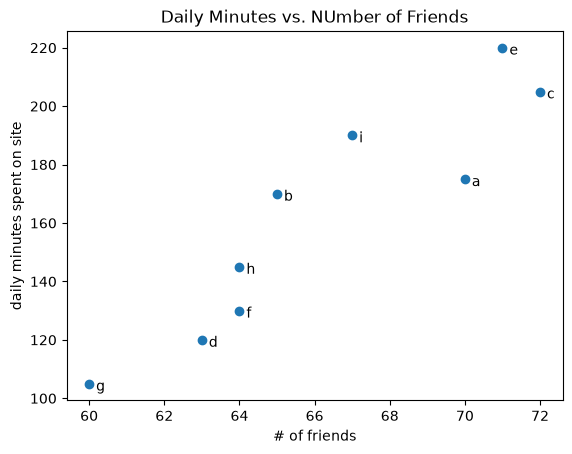

In [72]:
friends = [ 70, 65, 72, 63, 71, 64, 60, 64, 67]
minutes = [175, 170, 205, 120, 220, 130, 105, 145, 190]
labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i']

plt.scatter(friends, minutes)

for label, friend_count, minute_count in zip(labels, friends, minutes):
    plt.annotate(label, xy=(friend_count, minute_count), xytext=(5, -5), textcoords='offset points')

plt.title("Daily Minutes vs. NUmber of Friends")
plt.xlabel("# of friends")
plt.ylabel("daily minutes spent on site")
plt.show()

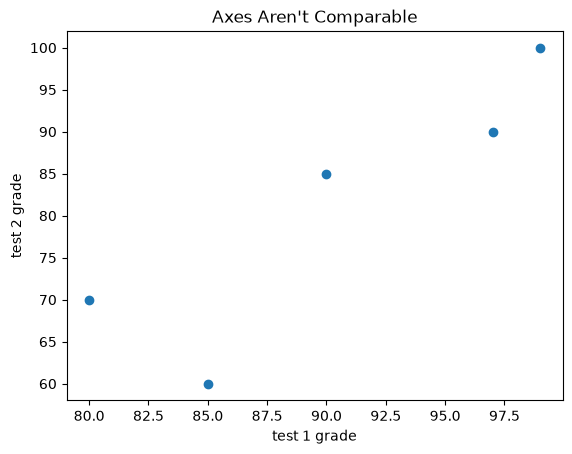

In [73]:
test_1_grades = [ 99, 90, 85, 97, 80]
test_2_grades = [100, 85, 60, 90, 70]

plt.scatter(test_1_grades, test_2_grades)
plt.title("Axes Aren't Comparable")
plt.xlabel("test 1 grade")
plt.ylabel("test 2 grade")
plt.show()

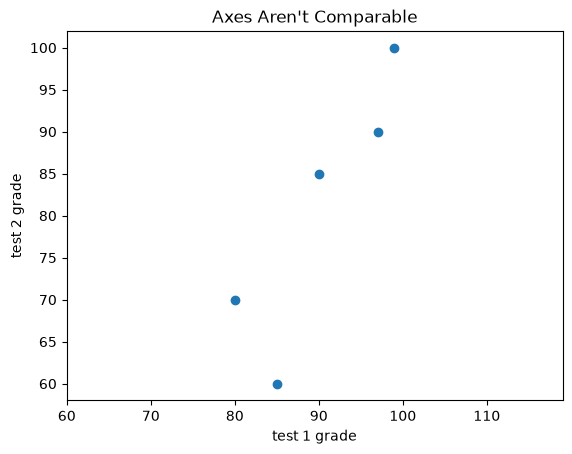

In [74]:
plt.scatter(test_1_grades, test_2_grades)
plt.title("Axes Aren't Comparable")
plt.xlabel("test 1 grade")
plt.ylabel("test 2 grade")
plt.axis("equal")
plt.show()

## LINEAR ALGEBRA

In [75]:
from typing import List
import math

Vectors

In [76]:
Vector = List[float]

def add(v: Vector, w: Vector) -> Vector:
    if len(v) != len(w):
        raise ValueError("Vectors must have the same length")
    return [v_i + w_i for v_i, w_i in zip(v, w)]

def subtract(v: Vector, w: Vector) -> Vector:
    if len(v) != len(w):
        raise ValueError("Vectors must have the same length")
    return [v_i - w_i for v_i, w_i in zip(v, w)]

def vector_sum(vectors: List[Vector]) -> Vector:
    if not vectors:
        raise ValueError("No vectors provided")

    num_elements = len(vectors[0])
    if not all(len(v) == num_elements for v in vectors):
        raise ValueError("Vectors must have the same length")

    return [sum(vector[i] for vector in vectors) for i in range(num_elements)]

def scalar_multiply(c: float, v: Vector) -> Vector:
    return [c * v_i for v_i in v]

def vector_mean(vectors: List[Vector]) -> Vector:
    n = len(vectors)
    return scalar_multiply(1/n, vector_sum(vectors))

def dot(v: Vector, w: Vector) -> float:
    if not len(v) == len(w):
        raise ValueError("Vectors must have the same length")
    return sum(v_i * w_i for v_i, w_i in zip(v, w))

def sum_of_squares(v: Vector) -> float:
     return dot(v, v)

def magnitude(v: Vector) -> float:
    return math.sqrt(sum_of_squares(v))

def squared_distance(v: Vector, w: Vector) -> float:
    return sum_of_squares(subtract(v, w))

def distance(v: Vector, w: Vector) -> float:
    return math.sqrt(squared_distance(v, w))

Matrices

In [77]:
from typing import Tuple
from typing import Callable

Matrix = List[List[float]]

def shape(a: Matrix) -> Tuple[int, int]:
    num_rows = len(a)
    num_cols = len(a[0]) if a else 0
    return num_rows, num_cols

def get_rows(a: Matrix, i: int) -> Vector:
    return a[i]

def get_columns(a: Matrix, j: int) -> Vector:
    return [a_i[j] for a_i in a]

def make_matrix(num_rows: int, num_cols: int, entry_fn: Callable[[int, int], float]) -> Matrix:
    return [[entry_fn(i, j) for j in range(num_cols)] for i in range(num_rows)]

def identity_matrix(n: int) -> Matrix:
    return make_matrix(n, n, lambda i, j: 1 if i == j else 0)

## Statistics

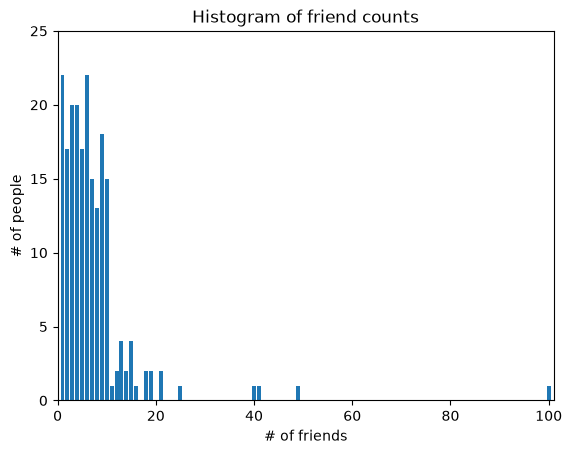

In [78]:
from collections import Counter
import matplotlib.pyplot as plt

num_friends = [100.0,49,41,40,25,21,21,19,19,18,18,16,15,15,15,15,14,14,13,13,13,13,12,12,11,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,8,8,8,8,8,8,8,8,8,8,8,8,8,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]

friend_counts = Counter(num_friends)
xss = range(101)
yss = [friend_counts[x] for x in xs]

plt.bar(xss, yss)
plt.axis((0, 101, 0, 25))
plt.title("Histogram of friend counts")
plt.xlabel("# of friends")
plt.ylabel("# of people")
plt.show()

Central tendencies

In [79]:
def mean(xs: List[float]) -> float:
    return sum(xs) / len(xs)

def _median_odd(xs: List[float]) -> float:
    return sorted(xs)[len(xs) // 2]

def _median_even(xs: List[float]) -> float:
    sorted_xs = sorted(xs)
    hi_midpoint = len(xs) // 2
    return (sorted_xs[hi_midpoint - 1] + sorted_xs[hi_midpoint]) / 2

def median(v: List[float]) -> float:
    return _median_even(v) if len(v) % 2 == 0 else _median_odd(v)

def quantile(xs: List[float], p: float) -> float:
    p_index = int(p * len(xs))
    return sorted(xs)[p_index]

def mode(x: List[float]) -> List[float]:
    counts = Counter(x)
    max_count = max(counts.values())
    return [x_i for x_i, count in counts.items() if count == max_count]

Dispersion

In [80]:
def data_range(xs: List[float]) -> float:
    return max(xs) - min(xs)

def de_mean(xs: List[float]) -> List[float]:
    x_bar = mean(xs)
    return [x - x_bar for x in xs]

def variance(xs: List[float]) -> float:
    if len(xs) < 2:
        raise ValueError("Variance requires at least two elements")

    n = len(xs)
    deviations = de_mean(xs)
    return sum_of_squares(deviations) / (n - 1)

def standard_deviation(xs: List[float]) -> float:
    return math.sqrt(variance(xs))

def interquartile_range(xs: List[float]) -> float:
    return quantile(xs, 0.75) - quantile(xs, 0.25)

Correlation

In [84]:
daily_minutes = [1,68.77,51.25,52.08,38.36,44.54,57.13,51.4,41.42,31.22,34.76,54.01,38.79,47.59,49.1,27.66,41.03,36.73,48.65,28.12,46.62,35.57,32.98,35,26.07,23.77,39.73,40.57,31.65,31.21,36.32,20.45,21.93,26.02,27.34,23.49,46.94,30.5,33.8,24.23,21.4,27.94,32.24,40.57,25.07,19.42,22.39,18.42,46.96,23.72,26.41,26.97,36.76,40.32,35.02,29.47,30.2,31,38.11,38.18,36.31,21.03,30.86,36.07,28.66,29.08,37.28,15.28,24.17,22.31,30.17,25.53,19.85,35.37,44.6,17.23,13.47,26.33,35.02,32.09,24.81,19.33,28.77,24.26,31.98,25.73,24.86,16.28,34.51,15.23,39.72,40.8,26.06,35.76,34.76,16.13,44.04,18.03,19.65,32.62,35.59,39.43,14.18,35.24,40.13,41.82,35.45,36.07,43.67,24.61,20.9,21.9,18.79,27.61,27.21,26.61,29.77,20.59,27.53,13.82,33.2,25,33.1,36.65,18.63,14.87,22.2,36.81,25.53,24.62,26.25,18.21,28.08,19.42,29.79,32.8,35.99,28.32,27.79,35.88,29.06,36.28,14.1,36.63,37.49,26.9,18.58,38.48,24.48,18.95,33.55,14.24,29.04,32.51,25.63,22.22,19,32.73,15.16,13.9,27.2,32.01,29.27,33,13.74,20.42,27.32,18.23,35.35,28.48,9.08,24.62,20.12,35.26,19.92,31.02,16.49,12.16,30.7,31.22,34.65,13.13,27.51,33.2,31.57,14.1,33.42,17.44,10.12,24.42,9.82,23.39,30.93,15.03,21.67,31.09,33.29,22.61,26.89,23.48,8.38,27.81,32.35,23.84]

daily_hours = [dm / 60 for dm in daily_minutes]

In [87]:
def covariance(xs: List[float], ys: List[float]) -> float:
    if len(xs) != len(ys):
        raise ValueError("xs and ys must have the same length")

    return dot(de_mean(xs), de_mean(ys)) / (len(xs) - 1)

def correlation(xs: List[float], ys: List[float]) -> float:
    stdev_x = standard_deviation(xs)
    stdev_y = standard_deviation(ys)
    if stdev_x > 0  and stdev_y > 0:
        return covariance(xs, ys) / stdev_x / stdev_y
    else:
        return 0

True 0.24736957366478227
True 0.24736957366478227


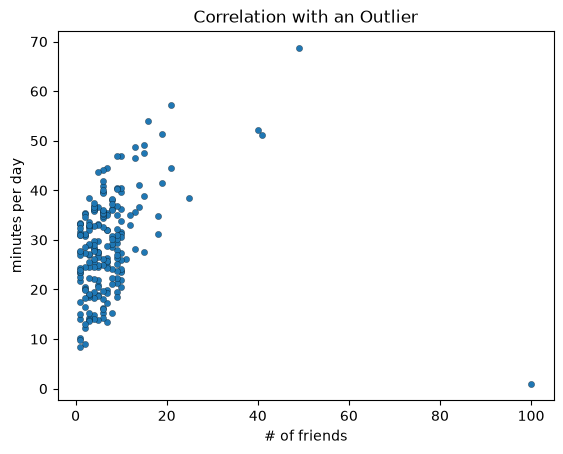

In [101]:
print(0.24 < correlation(num_friends, daily_minutes) < 0.25, correlation(num_friends, daily_minutes))
print(0.24 < correlation(num_friends, daily_hours) < 0.25, correlation(num_friends, daily_hours))

plt.scatter(num_friends, daily_minutes, s=20, edgecolors="black", linewidths=0.2)
plt.title("Correlation with an Outlier")
plt.ylabel("minutes per day")
plt.xlabel("# of friends")
plt.show()

True 0.5736792115665601
True 0.5736792115665601


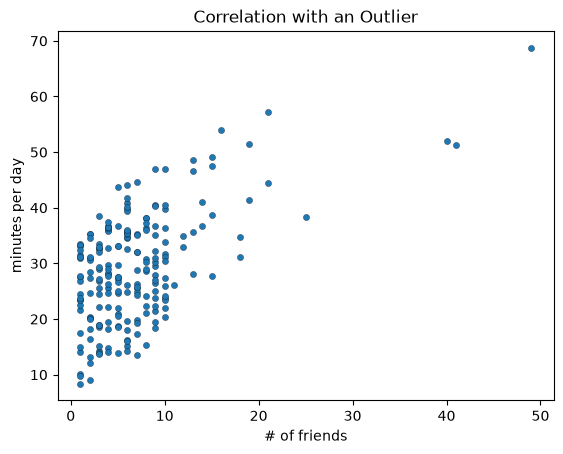

In [99]:
outlier = num_friends.index(100)

num_friends_good = [x for i, x in enumerate(num_friends) if i != outlier]
daily_minutes_good = [x for i, x in enumerate(daily_minutes) if i != outlier]

daily_hours_good = [dm / 60 for dm in daily_minutes_good]

print(0.57 < correlation(num_friends_good, daily_minutes_good) < 0.58, correlation(num_friends_good, daily_minutes_good))
print(0.57 < correlation(num_friends_good, daily_hours_good) < 0.58, correlation(num_friends_good, daily_hours_good))

plt.scatter(num_friends_good, daily_minutes_good, s=20, edgecolors="black", linewidths=0.2)
plt.title("Correlation with an Outlier")
plt.ylabel("minutes per day")
plt.xlabel("# of friends")
plt.show()